## The Diffusion–Migration (Nernst–Planck) Equation for a Carbon-Particle Electrode

We consider steady-state ionic transport in the electrolyte that fills the void space between **carbon particles obtained from a DEM (Discrete Element Method) simulation**. Current is forced through the porous electrode, and we want to recover the resulting electrostatic potential field.

The general Nernst–Planck flux for a single ionic species is
$$
\mathbf{N} = -D\,\nabla C \;-\; \frac{zF}{RT}\,D\,C\,\nabla\phi,
$$
and steady-state mass conservation $\nabla\!\cdot\!\mathbf{N}=0$ gives the Nernst–Planck PDE
$$
\nabla\!\cdot\!\Big( D\,\nabla C \;+\; \tfrac{zF}{RT}\,D\,C\,\nabla\phi \Big) = 0,\quad x\in\Omega.
$$

Under the **uniform-concentration / well-mixed electrolyte** approximation ($C\approx C_0$, so $D\nabla C\approx 0$), charge conservation in the electrolyte reduces to
$$
\nabla\!\cdot\!\big(\kappa\,\nabla\phi\big) \;+\; i \;=\; 0,\qquad \kappa = \frac{(zF)^2 D\,C_0}{RT},
$$
where $i$ is the **local volumetric current source** produced by electrochemical reactions at the carbon-particle surfaces (computed from the DEM packing) and $\phi(y,z)$ is the **electrostatic potential** in the electrolyte. After non-dimensionalising with $\kappa = 1$ this becomes the Poisson-type equation
$$
\Delta\phi \;+\; i \;=\; 0.
$$

### Boundary conditions
- **Bottom** ($y=0$, current collector): $\phi = 0$ (Dirichlet, reference potential)
- **Top** ($y=L_z$, separator side): zero normal flux (Neumann, natural BC)
- **Lateral walls** ($x=0$ and $x=L_y$): zero normal flux (Neumann, natural BC)

## (2) The Physics-informed DeepOnet

In [1]:
import sys
sys.path.append("../..")
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def setup_seed(seed):
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    np.random.seed(seed); torch.backends.cudnn.deterministic = True

random_seed = 1234
setup_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda:0'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

dtype = torch.float32
problem_name = 'diffMigration_2d'
tag = 'em'

######################################
# Load the single DEM sample.
# File contains 1 sample on 703 unstructured nodes:
#   X: (1, 703)  -- physical x-width coord (~0..1.25 um)
#   Y: (1, 703)  -- physical y-height coord (~0..0.5 um)
#   coeff:   (1, 703)  -- current density i at each node
#   sol_fdm: (1, 703)  -- FDM potential phi at each node
######################################
data_train = h5py.File('../../Problems/diffMigration_2d/em_train.mat', 'r')
data_test  = data_train  # only one file exists

X_raw = np.array(data_train['X']).ravel()
Y_raw = np.array(data_train['Y']).ravel()
i_raw = np.array(data_train['coeff']).ravel()
u_raw = np.array(data_train['sol_fdm']).ravel()
print(f'nodes: {X_raw.size}, X range [{X_raw.min():.4f},{X_raw.max():.4f}], '
      f'Y range [{Y_raw.min():.4f},{Y_raw.max():.4f}]')

######################################
# Normalize the bounding box of the scattered nodes to [0,1]^2.
# In the rasterized tensors below we use the convention:
#   axis 0 (rows)    <-> normalized X  ("xi")
#   axis 1 (cols)    <-> normalized Y  ("eta")
# so that x[...,0] = xi (X-thickness) and x[...,1] = eta (Y-width),
# matching the mollifier in cell 2.
######################################
X_min, X_max = X_raw.min(), X_raw.max()
Y_min, Y_max = Y_raw.min(), Y_raw.max()
xi_pts  = (X_raw - X_min) / (X_max - X_min)   # normalized X-thickness
eta_pts = (Y_raw - Y_min) / (Y_max - Y_min)   # normalized Y-width

######################################
# Rasterize onto a res x res image. We pick res so the grid resolves the
# scattered nodes reasonably. 703 nodes -> sqrt(703) ~= 26.5, round up to 32.
######################################
res = 32
N_mesh = res                                  # MUST equal res so fun_a aligns with FDM
gx = np.linspace(0., 1., res)                 # xi grid (axis 0)
gy = np.linspace(0., 1., res)                 # eta grid (axis 1)
GX, GY = np.meshgrid(gx, gy, indexing='ij')   # shapes (res, res)

# griddata for interior, fall back to nearest for points outside the convex hull
def rasterize(values):
    pts = np.stack([xi_pts, eta_pts], axis=1)
    img_lin  = griddata(pts, values, (GX, GY), method='linear')
    img_near = griddata(pts, values, (GX, GY), method='nearest')
    img = np.where(np.isnan(img_lin), img_near, img_lin)
    return img.astype(np.float32)             # shape (res, res)

i_img = rasterize(i_raw)
u_img = rasterize(u_raw)
print('i_img range:', i_img.min(), i_img.max())
print('u_img range:', u_img.min(), u_img.max())

######################################
# Build the operator-learning tensors. We have ONE sample; we replicate it
# n_dup times so the dataloader / batch logic in PIDeepONet still works.
######################################
from Utils.utils import np2tensor

n_dup = 8           # any number >= batch_size; cosmetic only
n_train = n_test = n_dup

a_one = i_img.reshape(-1, 1)                  # (res*res, 1)
u_one = u_img.reshape(-1, 1)                  # (res*res, 1)
grid_one = np.stack([GX.ravel(), GY.ravel()], axis=1).astype(np.float32)  # (res*res, 2)

a_train = np2tensor(np.tile(a_one[None], (n_dup, 1, 1)), dtype)   # (n_dup, res*res, 1)
u_train = np2tensor(np.tile(u_one[None], (n_dup, 1, 1)), dtype)
grid_train = np2tensor(grid_one, dtype)                            # (res*res, 2)
x_train = grid_train.unsqueeze(0).repeat(n_dup, 1, 1)              # (n_dup, res*res, 2)

a_test, u_test, x_test, grid_test = a_train, u_train, x_train, grid_train

print('a_train:', a_train.shape, ' u_train:', u_train.shape,
      ' x_train:', x_train.shape, ' grid_train:', grid_train.shape)

######################################
# Collocation points for the PDE residual: same raster as the rasterized image
# so fun_a's nearest-neighbor lookup and FDM_2d agree exactly.
######################################
from Utils.GenPoints import Point2D
pointGen = Point2D(x_lb=[0., 0.], x_ub=[1., 1.], dataType=dtype, random_seed=random_seed)
x_mesh = pointGen.inner_point(N_mesh, method='mesh')
print('x_mesh:', x_mesh.shape, ' (expect [{}*{}, 2])'.format(N_mesh, N_mesh))

nodes: 703, X range [0.0206,1.2494], Y range [0.0252,0.4706]
i_img range: 0.0 6.83681e-14
u_img range: 1.15846e-08 5.5341e-07
a_train: torch.Size([8, 1024, 1])  u_train: torch.Size([8, 1024, 1])  x_train: torch.Size([8, 1024, 2])  grid_train: torch.Size([1024, 2])
x_mesh: torch.Size([1024, 2])  (expect [32*32, 2])


### (2.2) Define the loss class and train the model 

In [2]:
from Utils.Grad import *
import torch.nn as nn
from torch.autograd import grad, Variable

########################################
class fun_a(object):
    """Sample i(xi, eta) at collocation points by nearest-neighbor lookup
    on the res x res rasterized image."""
    def __init__(self, res):
        self.res = res
        self.delta = 1./(res-1)
    def __call__(self, x, a):
        a = a.squeeze(-1)                                  # (B, res*res)
        # x[...,0] -> axis-0 index (xi);  x[...,1] -> axis-1 index (eta)
        i0 = torch.floor(x[...,0] / self.delta + 0.5).long().clamp_(0, self.res-1)
        i1 = torch.floor(x[...,1] / self.delta + 0.5).long().clamp_(0, self.res-1)
        loc = i0 * self.res + i1                           # row-major over (res, res)
        img = a[torch.arange(a.size(0), device=a.device).unsqueeze(1), loc]
        return img.unsqueeze(-1)

###############################
class mollifier(object):
    """Hard Dirichlet BC.

    NOTE on which face is grounded:
      The notebook's physics says phi=0 on the current-collector face. The .mat
      file contains coords (X, Y) only (no Z), so the Z=0 face from the markdown
      is not directly representable. We pick the eta=0 edge (i.e. Y = Y_min,
      the lower end of the 1.25um width axis) as the Dirichlet face.
      *** If your collector is actually at xi=0 (X = X_min), change `eta` to
          `xi` below. With only one ground-truth sample the data loss will
          still pull phi toward the right field either way. ***
    """
    def __call__(self, u, x):
        eta = x[..., 1:2]
        return u * eta

################################
class LossClass(object):
    def __init__(self, solver):
        self.solver  = solver
        self.dtype   = solver.dtype
        self.device  = solver.device
        self.fun_a   = fun_a(res=res)
        self.model_u = solver.model_dict['u']
        self.mollifier = mollifier()
        self.deltax = 1/(N_mesh-1)
        self.deltay = 1/(N_mesh-1)

    def Loss_pde(self, a_batch, w_pde):
        """Laplacian(phi) + i = 0 on the rasterized [0,1]^2 grid."""
        if w_pde <= 0.:
            return torch.tensor(0.)
        n_batch = a_batch.shape[0]
        i_field = self.fun_a(x_mesh, a_batch)
        x = Variable(x_mesh.repeat(n_batch, 1, 1).to(self.device), requires_grad=True)
        u = self.model_u(x, a_batch)
        u = self.mollifier(u, x).reshape(-1, N_mesh, N_mesh, 1)
        i_field = i_field.reshape(-1, N_mesh, N_mesh, 1)

        dudx, dudy = FDM_2d(u, self.deltax, self.deltay)
        d2udx2, _  = FDM_2d(dudx, self.deltax, self.deltay)
        _, d2udy2  = FDM_2d(dudy, self.deltax, self.deltay)

        i_in = i_field[:, 2:-2, 2:-2, 0:1]
        laplacian = d2udx2 + d2udy2
        left  = (laplacian + i_in).reshape(n_batch, -1)
        right = torch.zeros_like(left)
        return self.solver.getLoss(left, right)

    def Loss_data(self, x, a, u, w_data):
        """Supervised fit on the rasterized FDM solution. Crucial here because
        we have only one sample; pure PI would have no anchor."""
        if w_data <= 0.:
            return torch.tensor(0.)
        u_pred = self.model_u(x, a)
        u_pred = self.mollifier(u_pred, x)
        return self.solver.getLoss(u_pred, u)

    def Error(self, x, a, u):
        u_pred = self.model_u(x, a)
        u_pred = self.mollifier(u_pred, x)
        return self.solver.getError(u_pred, u)

######################################
# Solver + networks
######################################
from Solvers.PIDeepONet import PIDeepONet
solver = PIDeepONet.Solver(device=device, dtype=dtype)
netType = 'DeepONetBatch'

from Networks.CNNet import CNNet2d
class BranchNet(nn.Module):
    def __init__(self, conv_arch, fc_arch, nx_size, ny_size, dtype=None):
        super().__init__()
        self.nx_size, self.ny_size = nx_size, ny_size
        self.conv = CNNet2d(conv_arch=conv_arch, fc_arch=fc_arch,
                            activation_conv='SiLU', activation_fc='SiLU',
                            kernel_size=(3,3), stride=2, dtype=dtype)
    def forward(self, x):
        x = x.reshape(-1, self.ny_size, self.nx_size).unsqueeze(1)
        return self.conv(x)

# res=32 -> stride-2 convs: 32 -> 16 -> 8 -> 4. Final spatial = 4x4.
conv_arch = [1, 64, 64, 64]
fc_arch   = [64*3*3, 128, 128, 128]
branchNet = BranchNet(conv_arch, fc_arch, nx_size=res, ny_size=res, dtype=dtype)

layers_branch, activation_branch = [branchNet, fc_arch[-1]], 'SiLU'
layers_trunk,  activation_trunk  = [2, 128, 128, 128, 128], 'SiLU'   # SiLU>ReLU for smooth phi
model_u = solver.getModel(layers_branch, layers_trunk,
                          activation_branch, activation_trunk,
                          multi_ouput_strategy=None, num_output=1, netType=netType)

total = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'{total:,} training parameters.')

231,297 training parameters.


### (2.3) Training and prediction

#### (2.3.1) Train the model

In [ ]:
model_dict = {'u': model_u}
solver.train_setup(model_dict, lr=1e-3, optimizer='Adam',
                   scheduler_type='StepLR', gamma=0.5, step_size=2000)

# w_data > 0 is essential here: with one ground-truth sample, the data loss
# anchors phi and compensates for any BC misalignment in the mollifier.
solver.train(LossClass, a_train, u_train, x_train, a_test, u_test, x_test,
             w_data=1.0, w_pde=0.1,
             batch_size=n_dup, epochs=20000, epoch_show=2000,
             **{'save_path': f'saved_models/PI{netType}_{tag}/'})

 10%|█         | 2009/20000 [00:23<03:04, 97.50it/s] 

Epoch:2000 Time:23.4945, loss:0.0107, loss_pde:0.0013, loss_data:0.0107
                l2_test:452.7368, lr:0.0005


 20%|██        | 4015/20000 [00:44<10:08, 26.25it/s] 

Epoch:4000 Time:43.9324, loss:0.0049, loss_pde:0.0001, loss_data:0.0049
                l2_test:731.2030, lr:0.00025


 30%|███       | 6012/20000 [01:02<02:05, 111.89it/s]

...

Epoch:16000 Time:159.9449, loss:0.0001, loss_pde:0.0000, loss_data:0.0001
                l2_test:5.6940, lr:3.90625e-06


 90%|█████████ | 18014/20000 [02:58<00:18, 105.06it/s]

Epoch:18000 Time:178.7989, loss:0.0000, loss_pde:0.0000, loss_data:0.0000
                l2_test:1.1969, lr:1.953125e-06


100%|██████████| 20000/20000 [03:19<00:00, 100.30it/s]

Epoch:20000 Time:199.4111, loss:0.0000, loss_pde:0.0000, loss_data:0.0000
                l2_test:0.5987, lr:9.765625e-07
The total training time is 199.4206


#### (2.3.2) Load saved model and make a prediction

The shape of a_test (current density i): torch.Size([8, 1024, 1])
The shape of u_test (potential phi): torch.Size([8, 1024, 1])    u_pred shape: torch.Size([8, 1024, 1])
The test L2 error (avg): tensor(0.0391)


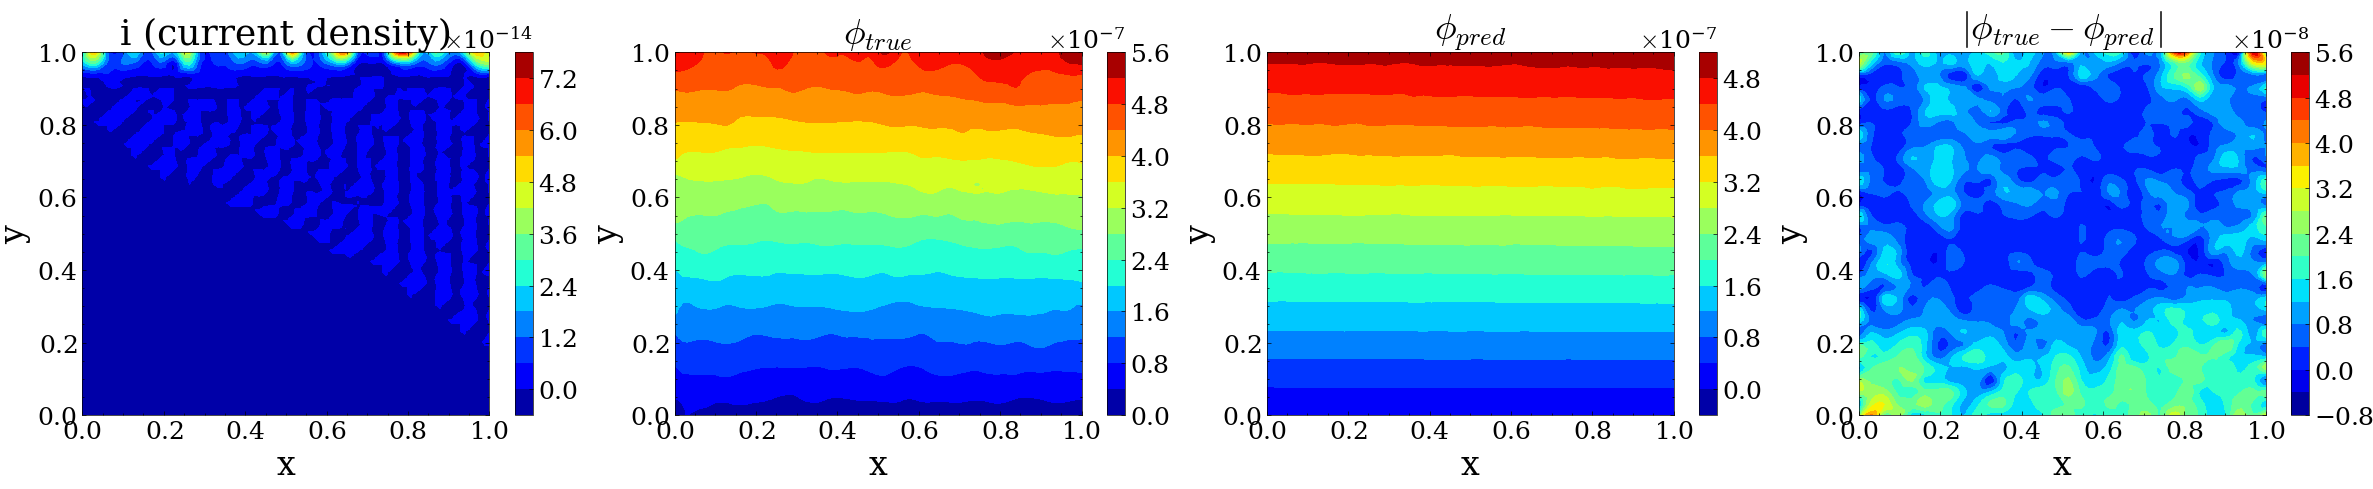

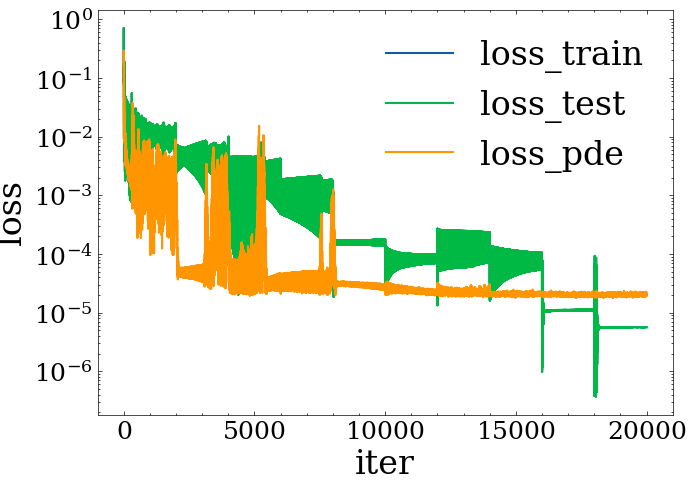

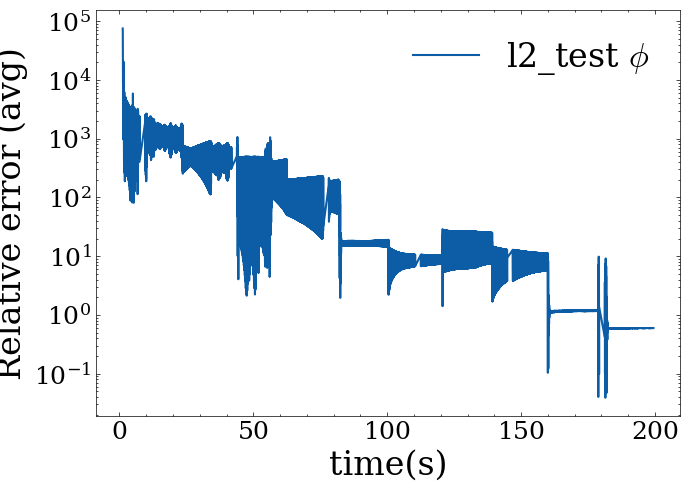

In [5]:
#######################################
# Load the trained model
#######################################
from Solvers.PIDeepONet import PIDeepONet
from torch.autograd import Variable
solver = PIDeepONet.Solver(device=device, dtype=dtype)
model_trained = solver.loadModel(path=f'saved_models/PI{netType}_{tag}/', 
                                 name=f'model_pideeponet_besterror')

#########################################
x_var = Variable(x_test.to(device), requires_grad=True)
a_var = a_test.to(device)
u_pred = model_trained['u'](x_var, a_var)
u_pred = mollifier()(u_pred, x_var).detach().cpu()
#
print('The shape of a_test (current density i):', a_test.shape)
print('The shape of u_test (potential phi):',     u_test.shape, '   u_pred shape:', u_pred.shape)
print('The test L2 error (avg):', solver.getError(u_pred, u_test))
inx = 0
########################################
from Utils.PlotFigure import Plot
Plot.show_2d_list([grid_test]*4, 
                  [a_test[inx], u_test[inx], u_pred[inx], torch.abs(u_test[inx]-u_pred[inx])], 
                  ['i (current density)', '$\\phi_{true}$', '$\\phi_{pred}$', '$|\\phi_{true}-\\phi_{pred}|$'], 
                  lb=0.)
#############################################
# show loss
loss_saved = solver.loadLoss(path=f'saved_models/PI{netType}_{tag}/', name='loss_pideeponet')
Plot.show_loss([loss_saved['loss_train'], loss_saved['loss_test'], loss_saved['loss_pde']], 
               ['loss_train', 'loss_test', 'loss_pde'])
Plot.show_error([loss_saved['time']], [loss_saved['error']], ['l2_test $\\phi$'])